In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df1 = pd.read_csv(r"E:\Pyhton code\Data Sets\archive\teen social media addiction\Teen_Mental_Health_Dataset.csv")
df2 = pd.read_csv(r"E:\Pyhton code\Data Sets\archive\teen social media addiction\Teen_Mental_Health_Dataset2.csv")

In [5]:
df1.head()

,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label
0,14,male,7.9,Instagram,7.4,2.9,3.01,1.5,low,2,2,1,0
1,19,female,1.9,TikTok,8.0,2.9,3.22,0.8,high,8,1,10,0
2,17,female,1.3,Instagram,7.6,0.5,3.92,0.0,high,2,4,2,0
3,15,male,7.4,TikTok,6.9,1.6,3.48,0.8,medium,1,7,9,0
4,15,female,4.7,Both,4.9,3.0,2.37,1.4,medium,3,5,2,0


In [6]:
df2.head()

,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,depression_risk
0,19,male,3.8,Instagram,6.5,1.7,2.77,1.2,low,6,6,medium
1,16,male,6.5,Other,5.8,0.6,2.57,0.2,medium,9,7,high
2,17,female,2.9,Other,7.0,1.2,3.04,1.7,high,3,2,low
3,19,female,7.9,TikTok,5.0,1.6,2.21,1.2,medium,10,8,medium
4,15,female,1.2,TikTok,8.8,0.9,3.61,1.9,high,1,2,low


In [7]:
print(df1.shape)
print(df2.shape)

(1200, 13)
(2500, 12)


In [8]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       1200 non-null   int64  
 1   gender                    1200 non-null   object 
 2   daily_social_media_hours  1200 non-null   float64
 3   platform_usage            1200 non-null   object 
 4   sleep_hours               1200 non-null   float64
 5   screen_time_before_sleep  1200 non-null   float64
 6   academic_performance      1200 non-null   float64
 7   physical_activity         1200 non-null   float64
 8   social_interaction_level  1200 non-null   object 
 9   stress_level              1200 non-null   int64  
 10  anxiety_level             1200 non-null   int64  
 11  addiction_level           1200 non-null   int64  
 12  depression_label          1200 non-null   int64  
dtypes: float64(5), int64(5), object(3)
memory usage: 122.0+ KB


In [9]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       2500 non-null   int64  
 1   gender                    2500 non-null   object 
 2   daily_social_media_hours  2500 non-null   float64
 3   platform_usage            2500 non-null   object 
 4   sleep_hours               2500 non-null   float64
 5   screen_time_before_sleep  2500 non-null   float64
 6   academic_performance      2500 non-null   float64
 7   physical_activity         2500 non-null   float64
 8   social_interaction_level  2500 non-null   object 
 9   stress_level              2500 non-null   int64  
 10  anxiety_level             2500 non-null   int64  
 11  depression_risk           2500 non-null   object 
dtypes: float64(5), int64(3), object(4)
memory usage: 234.5+ KB


In [11]:
#Standardize target column (depression level) in both datasets, convert into binary classification (0: No Depression, 1: Depression)
df2['depression_risk'] = df2['depression_risk'].apply(lambda x: 1 if x in ['medium', 'high'] else 0)

#rename depression_risk to depression_label in df2
df2.rename(columns={'depression_risk': 'depression_label'}, inplace=True)


In [13]:
df2["addiction_level"] = 0

In [14]:
#Make both dataset column order same
df2 = df2[df1.columns]

In [15]:
#Combining datasets
df = pd.concat([df1,df2], ignore_index=True)

#shuffle data
df = df.sample(
    frac=1,
    random_state=42
).reset_index(drop=True)

In [16]:
df.head()

,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label
0,18,male,4.2,Instagram,5.5,1.8,3.83,1.9,low,3,8,8,0
1,17,male,6.8,Other,5.3,1.8,2.00,1.0,high,10,10,0,1
2,15,female,5.9,Both,6.9,1.4,3.62,1.5,medium,3,9,1,0
3,14,female,6.3,Instagram,5.6,1.8,2.41,1.9,low,8,9,0,1
4,14,male,7.4,Instagram,8.9,2.4,2.29,1.1,low,10,4,8,0


In [17]:
df.shape

(3700, 13)

In [18]:
df.isnull().sum()

age                         0
gender                      0
daily_social_media_hours    0
platform_usage              0
sleep_hours                 0
screen_time_before_sleep    0
academic_performance        0
physical_activity           0
social_interaction_level    0
stress_level                0
anxiety_level               0
addiction_level             0
depression_label            0
dtype: int64

In [19]:
df["depression_label"].value_counts()

depression_label
0    2435
1    1265
Name: count, dtype: int64

In [20]:
#Check duplicate rows
df.duplicated().sum()

np.int64(0)

In [22]:
#Understanding data
df.describe(include='object')

,gender,platform_usage,social_interaction_level
count,3700,3700,3700
unique,2,4,3
top,male,Instagram,medium
freq,1860,1038,1257


In [24]:
#Data Analysis
print(df["depression_label"].value_counts())

print("\nPercentage Distribution:")
print(
    df["depression_label"]
    .value_counts(normalize=True) * 100
)

depression_label
0    2435
1    1265
Name: count, dtype: int64

Percentage Distribution:
depression_label
0    65.810811
1    34.189189
Name: proportion, dtype: float64


In [26]:
#numerical feature analysis
corr = df.corr(numeric_only=True)

print(corr["depression_label"].sort_values(ascending=False))

depression_label            1.000000
stress_level                0.612121
anxiety_level               0.542605
daily_social_media_hours    0.540451
screen_time_before_sleep    0.035891
age                         0.012820
physical_activity          -0.126546
addiction_level            -0.393996
sleep_hours                -0.472845
academic_performance       -0.571186
Name: depression_label, dtype: float64


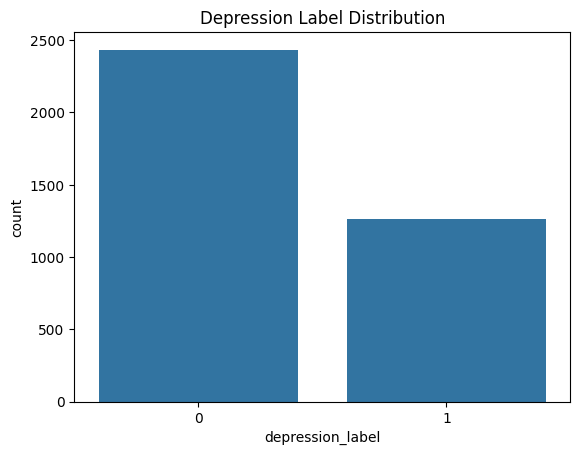

In [28]:
#target distribution plot
sns.countplot(x="depression_label", data=df)

plt.title("Depression Label Distribution")

plt.show()

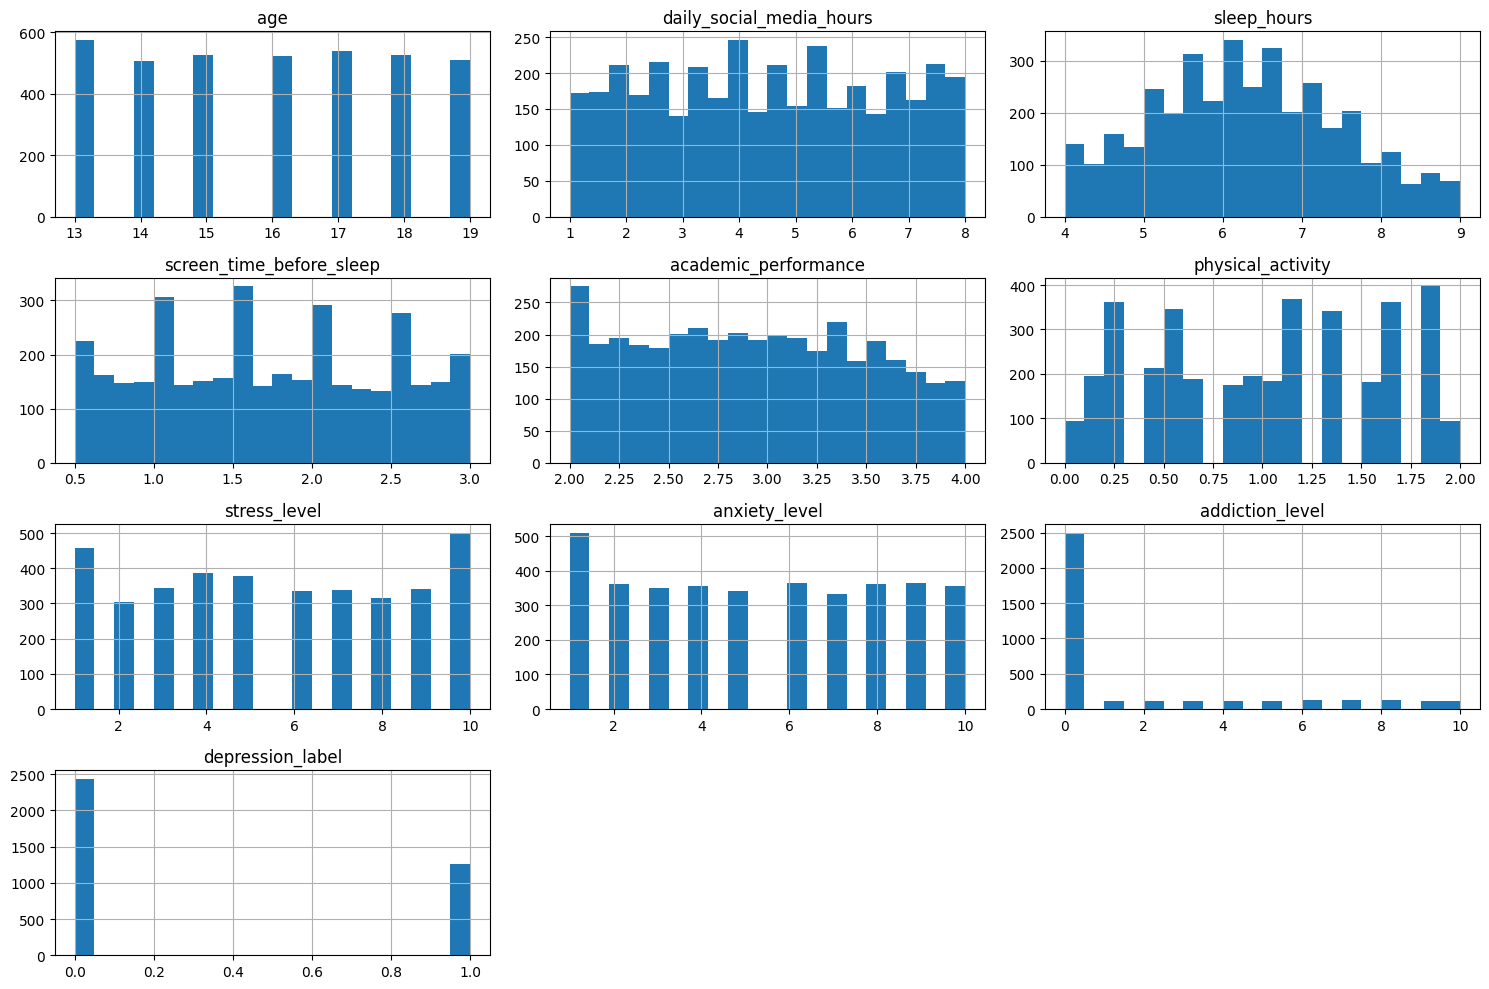

In [30]:
#numerical feature historgram
df.hist(
    figsize=(15,10),
    bins=20
)

plt.tight_layout()
plt.show()

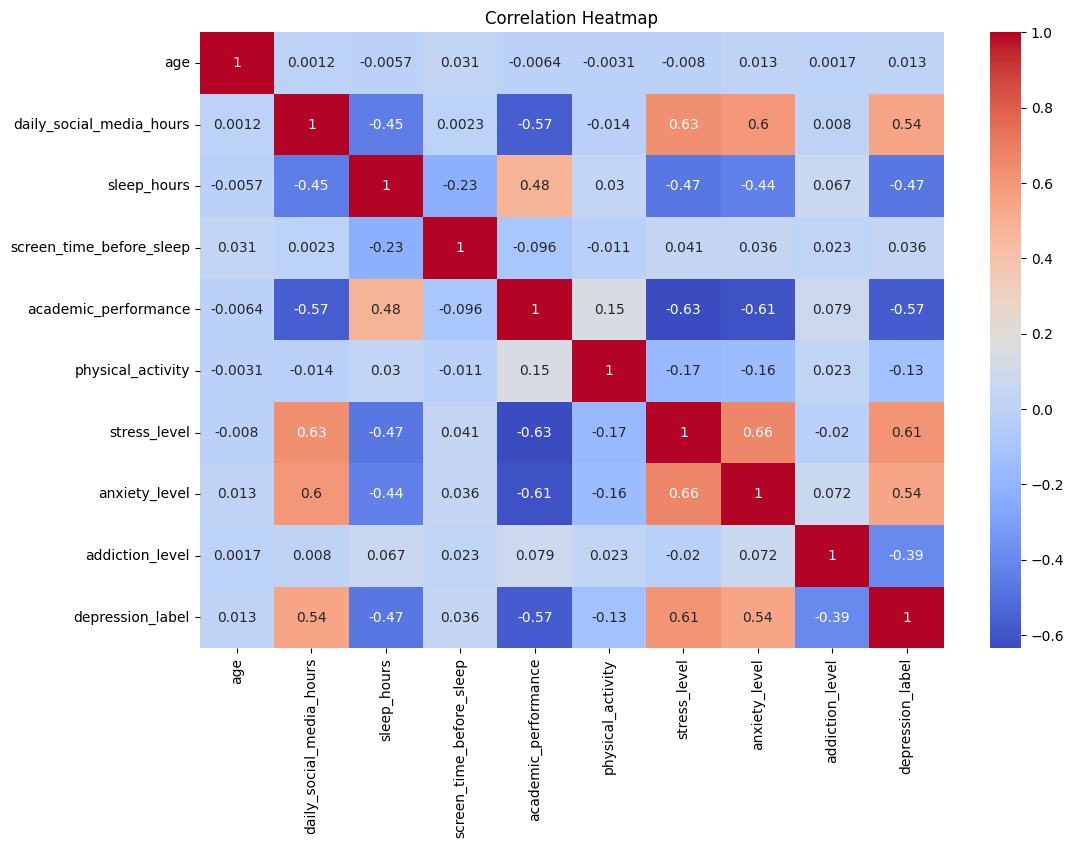

In [31]:
#Correlation heatmap
plt.figure(figsize=(12,8))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

In [32]:
cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
    print(f"\n===== {col} =====")
    print(df[col].value_counts())


===== gender =====
gender
male      1860
female    1840
Name: count, dtype: int64

===== platform_usage =====
platform_usage
Instagram    1038
Both         1019
TikTok       1011
Other         632
Name: count, dtype: int64

===== social_interaction_level =====
social_interaction_level
medium    1257
low       1225
high      1218
Name: count, dtype: int64


# Overall EDA Report — Teen Social Media Depression Dataset

* Dataset contains **3700 teen records** with social media, lifestyle, mental health, and academic features.

* Target variable (`depression_label`) is **moderately imbalanced**:

  * 65.8% non-depressed
  * 34.2% depressed

* Strong positive relationship found between depression and:

  * stress level
  * anxiety level
  * daily social media usage

* Strong negative relationship found between depression and:

  * sleep hours
  * academic performance

* Physical activity shows weak negative relation with depression.

* Age has almost no effect on depression prediction.

* Categorical features (`gender`, `platform_usage`, `social_interaction_level`) are well distributed and usable for modeling.

* Correlation analysis suggests:

  * more social media usage is linked with higher stress and anxiety
  * poor sleep and lower academic performance are linked with depression

* `addiction_level` shows unexpected negative correlation and should be inspected carefully during modeling.

* Dataset is clean:

  * no null values
  * no duplicate values
  * balanced categorical distributions

* Overall dataset is well-suited for:

  * Logistic Regression
  * Classification tasks
  * Feature engineering
  * Mental health prediction modeling

* Recommended next steps:

  * feature engineering
  * categorical encoding
  * feature scaling
  * train-test split
  * Logistic Regression model training
  * evaluation using Precision, Recall, F1, ROC-AUC.


In [33]:
#Feature engineering
# Sleep deficiency
df["sleep_deficiency"] = (
    8 - df["sleep_hours"]
)

# High screen usage
df["high_screen_time"] = (
    df["daily_social_media_hours"] > 6
).astype(int)

# Combined mental pressure
df["mental_pressure"] = (
    df["stress_level"] +
    df["anxiety_level"]
)

# Academic stress ratio
df["stress_academic_ratio"] = (
    df["stress_level"] /
    df["academic_performance"]
)

In [34]:
#One hot encoding
df = pd.get_dummies(
    df,
    columns=[
        "gender",
        "platform_usage",
        "social_interaction_level"
    ],
    drop_first=True
)

In [35]:
#Feature selection
corr = df.corr(numeric_only=True)

print(
    corr["depression_label"]
    .sort_values(ascending=False)
)

depression_label                   1.000000
stress_academic_ratio              0.672246
mental_pressure                    0.633527
stress_level                       0.612121
anxiety_level                      0.542605
daily_social_media_hours           0.540451
sleep_deficiency                   0.472845
high_screen_time                   0.414123
platform_usage_Other               0.142200
screen_time_before_sleep           0.035891
age                                0.012820
social_interaction_level_low      -0.002201
gender_male                       -0.026118
social_interaction_level_medium   -0.030988
platform_usage_Instagram          -0.045510
platform_usage_TikTok             -0.051979
physical_activity                 -0.126546
addiction_level                   -0.393996
sleep_hours                       -0.472845
academic_performance              -0.571186
Name: depression_label, dtype: float64


In [37]:
#Separate feature and target
X = df.drop("depression_label", axis=1)

y = df["depression_label"]

In [ ]:
#trian test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y #preserve class distrbution in train and test set.
)

In [39]:
#Feature scaling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [40]:
print(X_train_scaled.shape)
print(X_test_scaled.shape)

print(y_train.shape)
print(y_test.shape)

(2960, 19)
(740, 19)
(2960,)
(740,)


In [41]:
#model building
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

model.fit(X_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


1. initialize random weights
2. compute z = wTx+b
3. apply sigmoid
4. compute cross-entropy loss
5. compute gradients
6. update weights
7. repeat until loss minimized

In [42]:
#make prediction
y_pred = model.predict(X_test_scaled)

# Probability predictions
y_prob = model.predict_proba(X_test_scaled)[:, 1]

In [43]:
#Model performance evlaution
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.9067567567567567


In [44]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[454  33]
 [ 36 217]]


In [45]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.93      0.93      0.93       487
           1       0.87      0.86      0.86       253

    accuracy                           0.91       740
   macro avg       0.90      0.89      0.90       740
weighted avg       0.91      0.91      0.91       740



In [46]:
from sklearn.metrics import roc_auc_score

auc = roc_auc_score(y_test, y_prob)

print("ROC-AUC:", auc)

ROC-AUC: 0.9757326862049654


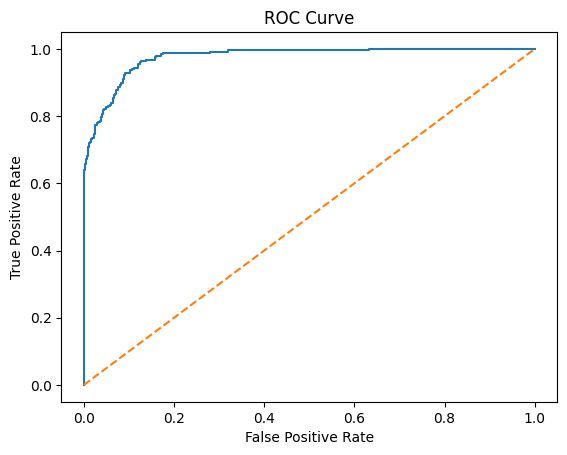

In [47]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.plot(fpr, tpr)

plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.show()

# Logistic Regression Project Report

## Title

Teen Social Media Depression Prediction Using Logistic Regression

---

## Dataset Shape

* Total Samples: **3700**
* Features: **13+ engineered features**
* Target Variable: `depression_label`

---

## Steps Performed

* Combined two teen social media datasets
* Handled feature mismatch
* Performed Exploratory Data Analysis (EDA)
* Analyzed correlations and feature distributions
* Created new engineered features:

  * sleep deficiency
  * mental pressure
  * high screen time
* Applied One-Hot Encoding on categorical features
* Performed Feature Scaling using StandardScaler
* Split dataset into train and test sets
* Built Logistic Regression model
* Evaluated model using:

  * Accuracy
  * Confusion Matrix
  * Precision
  * Recall
  * F1-Score
  * ROC-AUC

---

## Key Insights

* Higher stress and anxiety strongly increase depression probability
* More social media usage is associated with higher depression risk
* Lower sleep hours and poor academic performance are linked with depression
* Logistic Regression successfully captured behavioral patterns in teen data
* Dataset showed reasonably linear relationships, making Logistic Regression effective

---

## Model Evaluation

| Metric    | Score  |
| --------- | ------ |
| Accuracy  | 90.67% |
| Precision | 87%    |
| Recall    | 86%    |
| F1-Score  | 86%    |
| ROC-AUC   | 0.975  |

### Confusion Matrix

* Correctly detected most depressed and non-depressed teens
* Very low false predictions
* ROC curve showed excellent class separation

---

## Conclusion

The Logistic Regression model performed very well on the teen social media depression dataset. The model successfully learned relationships between stress, anxiety, social media usage, sleep patterns, and depression risk. High ROC-AUC and balanced Precision-Recall scores indicate strong classification performance. The project also demonstrated the complete machine learning workflow including EDA, feature engineering, preprocessing, model training, and evaluation using Logistic Regression.
